# 1. Reproducibility Configuration

- ensures experimental reproducibility.
- *SEED = 42* used for Python, NumPy, and TensorFlow.
- helped to reduce randomness of dataset shuffling, weight initialization and augmentation operations during training phase.

In [ ]:
import os, random, numpy as np, tensorflow as tf

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


## 2. Import Dependencies

- imported modules to support data preprocessing, model development, evaluation, and visualization.
- **TensorFlow / Keras** - implement and train the model
- **NumPy** - numerical computations
- **Matplotlib** and **Seaborn** - graphical representation and visualization


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os



## 3. Mount Google Drive

- *dataset* and *experiment files* stored in **Google Colab**
- this approach ease dataset management and a faster access during training and evaluation

&rarr; mount Google Drive to provide access to dataset, trained models for training and evaluation

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!unzip -qo "/content/drive/MyDrive/FER2013.zip" -d "/content/"

## 4. FER2013 Loading and Preprocessing

- *FER2013* dataset was loaded from **train** and **test** directories using the *TensorFlow/Keras* **ImageDataGenerator** utility.

- images resized to **48x48 grayscale** to match RS-Xception requirements.

- during training (train_datagen), pixel values were normalized in range [0, 1] (`rescale=1./255`)

- *data augmentation techniques* used: rotation range, width and height shifts, zoom transormation,**Brightness Range** to randomly adjusts the brightness of the images by a factor between 0.85 and 1.15, helping the model generalize to varying lighting conditions (extra data augmentation technique, unused in the other models).

&rarr; create small variations to improve model robustness.

- for test dataset (`val_datagen`) - only normalization (`rescale=1./255`) applied to ensure the unbiased evaluation of the model

- training images (`train_gen`) were shuffled at each epoch, while test images (`val_gen`) were not shuffled.



In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    brightness_range=(0.85, 1.15),
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

TRAIN_PATH = '/content/FER2013/train'
VAL_PATH = '/content/FER2013/test'




train_gen = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(48, 48),
    color_mode='grayscale',
    class_mode='categorical',
    batch_size=16,
    shuffle=True,
    seed=SEED
)

val_gen = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=(48, 48),
    color_mode='grayscale',
    class_mode='categorical',
    batch_size=16,
    shuffle=False
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


## 5. RS-Xception Model Architecture

The RS-Xception model is a lightweight convolutional neural network designed specifically for efficient facial emotion recognition on mobile devices. It combines two key techniques:

- **Separable Convolutions**: These reduce the number of trainable parameters and computations compared to standard convolutions, making the model faster and more suitable for deployment.
- **Squeeze-and-Excitation (SE) Blocks**: These introduce channel-wise attention, allowing the model to focus on the most informative features in each convolutional block.

### Model Overview:
- **Input shape**: 48×48×3 (resized facial images)
- **Convolution blocks**: Three stacked blocks with increasing filter sizes (128, 256, 512), each followed by an SE block
- **Pooling**: Global Average Pooling to reduce feature dimensions
- **Dense layers**: Fully connected layer with 128 units and dropout (0.3) for regularization
- **Output**: Softmax layer with 7 units (one per emotion class)

In [ ]:

# RS-Xception Model Definition
from tensorflow.keras import layers, models

# Squeeze-and-Excitation Block (attention mechanism)
def SE_Block(inputs, ratio=8):
    filters = inputs.shape[-1]
    se = layers.GlobalAveragePooling2D()(inputs)
    se = layers.Dense(filters // ratio, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    x = layers.multiply([inputs, se])
    return x

# Residual + SE Module (as in Figure 3)  -> update like in paper
def RSX_Module(x, filters):
    shortcut = x

    # Channel projection if needed
    if x.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # Two Separable Convs
    x = layers.SeparableConv2D(filters, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.SeparableConv2D(filters, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # SE block
    x = SE_Block(x)

    # Residual connection
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)

    # Spatial reduction
    x = layers.MaxPooling2D((2, 2))(x)

    return x


# RS-Xception Full Model
def RS_Xception(input_shape=(48, 48, 1), num_classes=7):
    inputs = layers.Input(shape=input_shape)

    # Initial Conv layer (3x3)
    x = layers.Conv2D(32, (3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # 5x RSX Modules with increasing filters
    for filters in [32, 64, 128, 256, 512]:
        x = RSX_Module(x, filters)

    # Final 3x3x7 Conv → GAP → Softmax
    x = layers.Conv2D(num_classes, (3, 3), padding='same')(x)
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Activation('softmax')(x)

    model = models.Model(inputs, outputs)
    return model


# Create and summarize the model
model = RS_Xception()
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 48, 48,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 48, 48,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 48, 48,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 48, 48,    │      1,344 │ re_lu[0][0]       │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 48, 48,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 48, 48,    │      1,344 │ re_lu_1[0][0]     │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 48, 48,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ re_lu_2[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │        132 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        160 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 48, 48,    │          0 │ re_lu_2[0][0],    │
│                     │ 32)               │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 48, 48,    │          0 │ multiply[0][0],   │
│                     │ 32)               │            │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 48, 48,    │          0 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 24, 24,    │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 847,747 (3.23 MB)

 Trainable params: 841,795 (3.21 MB)

 Non-trainable params: 5,952 (23.25 KB)

## 6. Compile the model

- before training, the model was compiled by defining the *optimization strategy*, *loss function*, and *evaluation metrics*.

- **Adam** optimizer was selected due to its adaptive learning rate mechanism, which combines the advantages of momentum and adaptive gradient optimization.

- Initial **learning rate** of 0.001 - used to provide stable and efficient convergence during training.

- Loss function is **Focal Loss**, since task involve multi-class classification. (Extra aspect used than `RSX_V3` is **label_smoothing=0.1**)

- **Accuracy** - used as the primary evaluation metric to monitor model performance throughout training and validation.

In [ ]:
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
from tensorflow.keras import backend as K

def focal_loss(gamma=2.0, alpha=0.25, label_smoothing=0.1):
    def loss(y_true, y_pred):
        num_classes = tf.cast(tf.shape(y_true)[-1], tf.float32)
        y_true = y_true * (1.0 - label_smoothing) + (label_smoothing / num_classes)
        y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())
        ce = -y_true * K.log(y_pred)
        weight = alpha * K.pow(1 - y_pred, gamma)
        return K.mean(weight * ce)
    return loss



model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=focal_loss(gamma=2.0, alpha=0.25, label_smoothing=0.1),
    metrics=['accuracy']
)


## 7. Training Configuration and Callbacks

- before training, several strategies were employed to improve convergence, prevent overfitting and address class imbalance of FER2013 dataset.

- **Cosine Scheduler** controls how the learning rate changes during training. (difference than *ReduceLROnPlateau* is that is not adaptive &rarr; follow a fixed schedule for learning rate)
- **Early Stopping** with `patience=20` monitors the validation loss and terminates training when no further improvement is observed. The best-performing model weights are automatically restored.

- **Model Checkpoint** - saves the model that achieves the highest validation accuracy, ensuring that the best-performing version is preserved for evaluation and future deployment.

- **Class Weights** were computed automatically from the training dataset to compensate for class imbalance &rarr; assigns higher importance to underrepresented emotion classes during optimization.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, LearningRateScheduler
from sklearn.utils.class_weight import compute_class_weight
import math

def cosine_decay(epoch):
    max_epochs = 150
    initial_lr = 0.001
    cosine = (math.cos(math.pi * epoch / max_epochs) + 1) / 2
    return initial_lr * cosine

cosine_scheduler = LearningRateScheduler(cosine_decay, verbose=1)


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)


checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/RSX_v4_best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights = dict(enumerate(class_weights))



In [ ]:
EPOCHS = 150

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stop, cosine_scheduler, checkpoint]
)




Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/150
1792/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2846 - loss: 0.0460
Epoch 1: val_accuracy improved from None to 0.32474, saving model to /content/drive/MyDrive/RSX_v4_best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/RSX_v4_best_model.h5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 113s 40ms/step - accuracy: 0.3450 - loss: 0.0429 - val_accuracy: 0.3247 - val_loss: 0.0442 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.0009998903417374227.
Epoch 2/150
1792/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4533 - loss: 0.0369
Epoch 2: val_accuracy improved from 0.32474 to 0.35860, saving model to /content/drive/MyDrive/RSX_v4_best_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/RSX_v4_best_model.h5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.4642 - loss: 0.0364 - val_accuracy: 0.3586 - val_loss: 0.0432 - learning_rate: 9.9989e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.0009995614150494292.
Epoch 3/150
1794/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5020 - loss: 0.0344
Epoch 3: val_accuracy improved from 0.35860 to 0.49094, saving model to /content/drive/MyDrive/RSX_v4_best_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/RSX_v4_best_model.h5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.5122 - loss: 0.0337 - val_accuracy: 0.4909 - val_loss: 0.0354 - learning_rate: 9.9956e-04

Epoch 4: LearningRateScheduler setting learning rate to 0.0009990133642141358.
Epoch 4/150
1792/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5362 - loss: 0.0320
Epoch 4: val_accuracy improved from 0.49094 to 0.49721, saving model to /content/drive/MyDrive/RSX_v4_best_model.h5



Epoch 4: finished saving model to /content/drive/MyDrive/RSX_v4_best_model.h5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.5366 - loss: 0.0320 - val_accuracy: 0.4972 - val_loss: 0.0333 - learning_rate: 9.9901e-04

Epoch 5: LearningRateScheduler setting learning rate to 0.0009982464296247522.
Epoch 5/150
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5502 - loss: 0.0306
Epoch 5: val_accuracy improved from 0.49721 to 0.55015, saving model to /content/drive/MyDrive/RSX_v4_best_model.h5


...


Epoch 21: finished saving model to /content/drive/MyDrive/RSX_v4_best_model.h5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.6781 - loss: 0.0241 - val_accuracy: 0.6381 - val_loss: 0.0268 - learning_rate: 9.5677e-04

Epoch 22: LearningRateScheduler setting learning rate to 0.0009524135262330098.
Epoch 22/150
1792/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6919 - loss: 0.0234
Epoch 22: val_accuracy did not improve from 0.63806
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.6848 - loss: 0.0238 - val_accuracy: 0.6317 - val_loss: 0.0275 - learning_rate: 9.5241e-04

Epoch 23: LearningRateScheduler setting learning rate to 0.0009478558801197064.
Epoch 23/150
1792/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6926 - loss: 0.0234
Epoch 23: val_accuracy did not improve from 0.63806
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.6889 - loss: 0.0236 - val_accuracy: 0.6220 - val_loss: 0.0278 - learning_rate: 9.4786e-04

Epoch 24: LearningRateSc


Epoch 24: finished saving model to /content/drive/MyDrive/RSX_v4_best_model.h5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.6935 - loss: 0.0233 - val_accuracy: 0.6495 - val_loss: 0.0266 - learning_rate: 9.4310e-04

Epoch 25: LearningRateScheduler setting learning rate to 0.0009381533400219318.
Epoch 25/150
1793/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7045 - loss: 0.0229
Epoch 25: val_accuracy did not improve from 0.64948
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.6999 - loss: 0.0231 - val_accuracy: 0.6330 - val_loss: 0.0275 - learning_rate: 9.3815e-04

Epoch 26: LearningRateScheduler setting learning rate to 0.0009330127018922194.
Epoch 26/150
1792/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7095 - loss: 0.0224
Epoch 26: val_accuracy did not improve from 0.64948
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.7017 - loss: 0.0228 - val_accuracy: 0.6353 - val_loss: 0.0270 - learning_rate: 9.3301e-04

Epoch 27: LearningRateSc


Epoch 27: finished saving model to /content/drive/MyDrive/RSX_v4_best_model.h5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.7080 - loss: 0.0225 - val_accuracy: 0.6514 - val_loss: 0.0261 - learning_rate: 9.2768e-04

Epoch 28: LearningRateScheduler setting learning rate to 0.0009221639627510075.
Epoch 28/150
1793/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7173 - loss: 0.0220
Epoch 28: val_accuracy did not improve from 0.65143
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.7121 - loss: 0.0223 - val_accuracy: 0.6399 - val_loss: 0.0268 - learning_rate: 9.2216e-04

Epoch 29: LearningRateScheduler setting learning rate to 0.0009164606203550497.
Epoch 29/150
1792/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7213 - loss: 0.0219
Epoch 29: val_accuracy did not improve from 0.65143
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.7165 - loss: 0.0221 - val_accuracy: 0.6456 - val_loss: 0.0268 - learning_rate: 9.1646e-04

Epoch 30: LearningRateSc


Epoch 34: finished saving model to /content/drive/MyDrive/RSX_v4_best_model.h5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.7400 - loss: 0.0209 - val_accuracy: 0.6537 - val_loss: 0.0271 - learning_rate: 8.8526e-04

Epoch 35: LearningRateScheduler setting learning rate to 0.0008784975278258782.
Epoch 35/150
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7442 - loss: 0.0205
Epoch 35: val_accuracy improved from 0.65366 to 0.66049, saving model to /content/drive/MyDrive/RSX_v4_best_model.h5



Epoch 35: finished saving model to /content/drive/MyDrive/RSX_v4_best_model.h5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - accuracy: 0.7408 - loss: 0.0208 - val_accuracy: 0.6605 - val_loss: 0.0264 - learning_rate: 8.7850e-04

Epoch 36: LearningRateScheduler setting learning rate to 0.0008715724127386972.
Epoch 36/150
1794/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7490 - loss: 0.0205
Epoch 36: val_accuracy did not improve from 0.66049
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - accuracy: 0.7472 - loss: 0.0206 - val_accuracy: 0.6524 - val_loss: 0.0270 - learning_rate: 8.7157e-04

Epoch 37: LearningRateScheduler setting learning rate to 0.0008644843137107057.
Epoch 37/150
1794/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7570 - loss: 0.0200
Epoch 37: val_accuracy did not improve from 0.66049
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - accuracy: 0.7496 - loss: 0.0205 - val_accuracy: 0.6519 - val_loss: 0.0274 - learning_rate: 8.6448e-04

Epoch 38: LearningRateSc

## 9. Model Export and TensorFlow Lite Conversion

- After training, the best-performing RS-Xception model was saved in Keras format (`.h5`) for future reuse and evaluation.

- To enable deployment within the **Face2Mood mobile application**, the trained model was subsequently converted to the TensorFlow Lite (`.tflite`) format.

- **TensorFlow Lite** provides a lightweight representation of the model that is optimized for on-device inference, reducing storage requirements and enabling efficient execution for mobile hardware.

- Default TensorFlow Lite optimizations (`tf.lite.Optimize.DEFAULT`) were applied during the conversion process in order to improve deployment efficiency while preserving model performance.


In [ ]:
model.save('/content/drive/MyDrive/RSX_v4_best_model.h5')


converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]

tflite_model = converter.convert()  # conversion to .tflite

with open('/content/drive/MyDrive/RSX_V4_mobile_safe.tflite', 'wb') as f:
    f.write(tflite_model)

print("Saved RSX_V4_mobile_safe.tflite")

Saved artifact at '/tmp/tmpdy0cw_ue'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 48, 48, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  132816147124240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132816147123472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132816147125584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132816147122704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132816147124048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132816147126544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132816147125776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132816147126736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132816147125968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132816147127696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132816147127888:

## 10. Results, Graphs, and Metrics

### 10.1. Training Loss / Validation Loss Curves

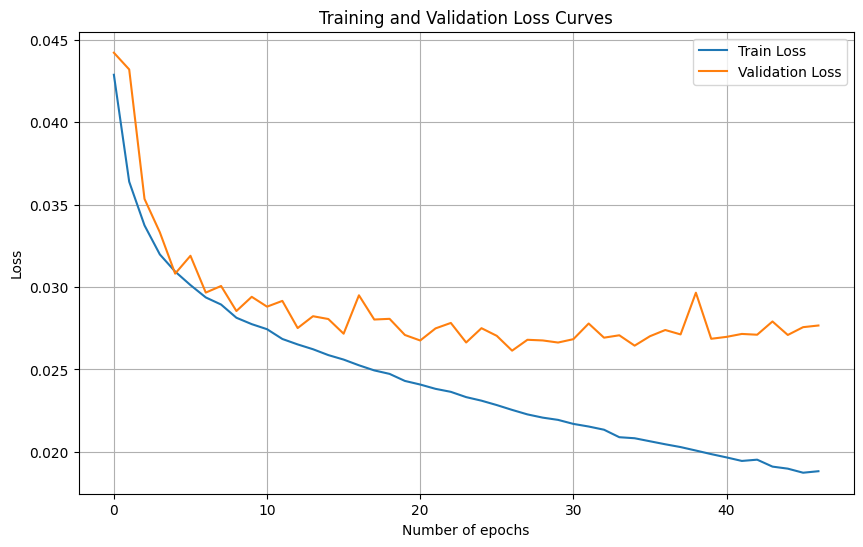

In [ ]:
import matplotlib.pyplot as plt

hist = history.history if hasattr(history, "history") else history

plt.figure(figsize=(10, 6))
plt.plot(hist['loss'], label='Train Loss')
plt.plot(hist['val_loss'], label='Validation Loss')
plt.xlabel('Number of epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
best_epoch = np.argmin(hist['val_loss']) + 1

print("Loss Summary")
print("----------------------------")
print(f"Best Epoch (Validation Loss): {best_epoch}")
print(f"Best Validation Loss: {min(hist['val_loss']):.4f}")
print(f"Final Training Loss: {hist['loss'][-1]:.4f}")
print(f"Final Validation Loss: {hist['val_loss'][-1]:.4f}")

Loss Summary
----------------------------
Best Epoch (Validation Loss): 27
Best Validation Loss: 0.0261
Final Training Loss: 0.0188
Final Validation Loss: 0.0277


### 10.2. Training Accuracy / Validation Accuracy Curves

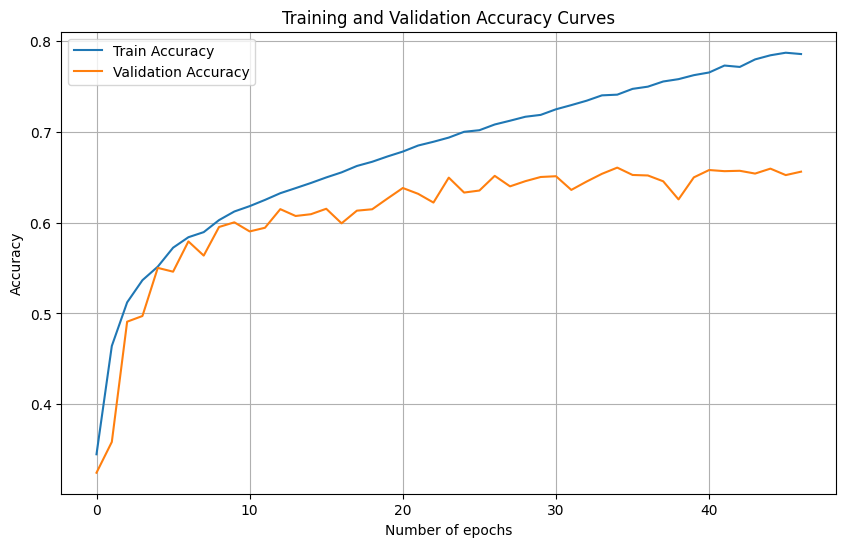

In [ ]:
import matplotlib.pyplot as plt

hist = history.history if hasattr(history, "history") else history

plt.figure(figsize=(10, 6))
plt.plot(hist['accuracy'], label='Train Accuracy')
plt.plot(hist['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Number of epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy Curves')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
best_epoch = np.argmax(hist['val_accuracy']) + 1

print("Accuracy Summary:")
print("---------------------------------")
print(f"Best Epoch (Validation Accuracy): {best_epoch}")
print(f"Best Validation Accuracy: {max(hist['val_accuracy'])*100:.2f}%")
print(f"Final Training Accuracy: {hist['accuracy'][-1]*100:.2f}%")
print(f"Final Validation Accuracy: {hist['val_accuracy'][-1]*100:.2f}%")

Accuracy Summary:
---------------------------------
Best Epoch (Validation Accuracy): 35
Best Validation Accuracy: 66.05%
Final Training Accuracy: 78.55%
Final Validation Accuracy: 65.60%


### 10.3.1 Raw Confusion Matrix

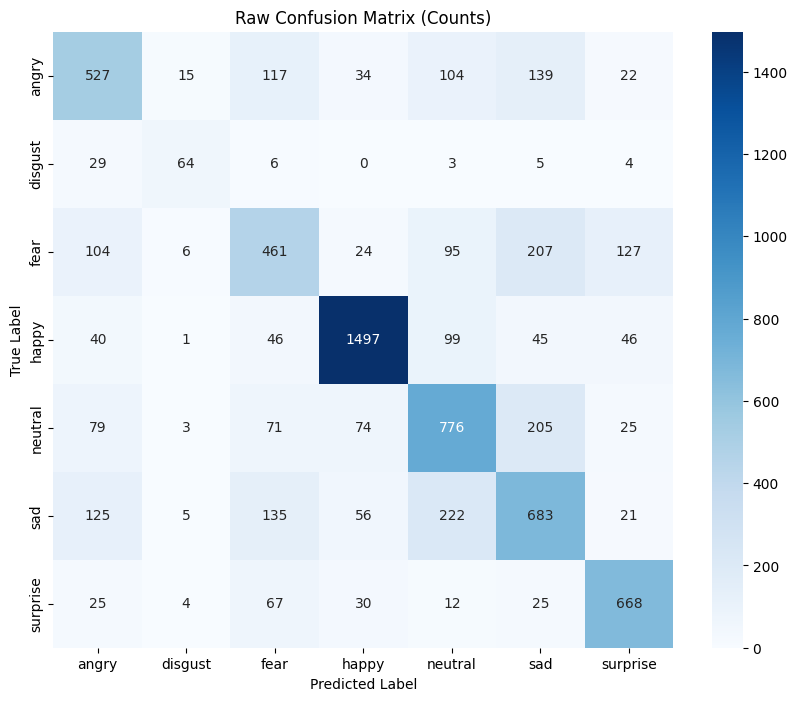

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


# Plotting the raw confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Raw Confusion Matrix (Counts)')
plt.show()

### 10.3.2 Normalized Confusion Matrix

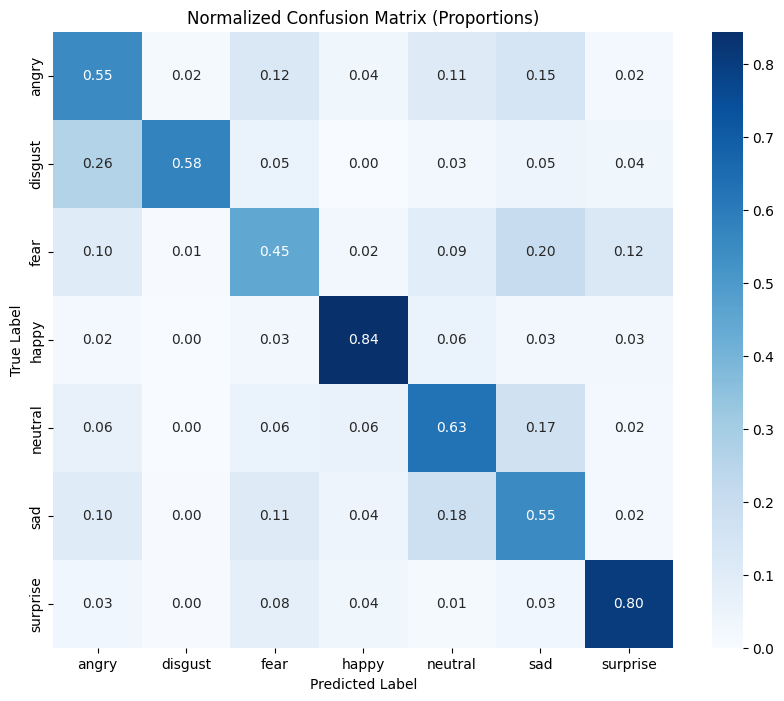

In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Normalize the confusion matrix by rows (true labels) to get values between 0 and 1
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plotting the normalized confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalized Confusion Matrix (Proportions)')
plt.show()

### 10.4. Per-Class Accuracy

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix

# Calculate per-class accuracy
cm_per_class = confusion_matrix(y_true, y_pred_classes)
per_class_accuracy = cm_per_class.diagonal() / cm_per_class.sum(axis=1)

# Create a DataFrame for per-class accuracy
per_class_accuracy_df = pd.DataFrame({
    'Emotion': class_names,
    'Accuracy': per_class_accuracy
})

print("Per-Class Accuracy:")
print(per_class_accuracy_df.to_markdown(index=False))

Per-Class Accuracy:
| Emotion   |   Accuracy |
|:----------|-----------:|
| angry     |   0.550104 |
| disgust   |   0.576577 |
| fear      |   0.450195 |
| happy     |   0.843856 |
| neutral   |   0.629359 |
| sad       |   0.547715 |
| surprise  |   0.803851 |


/tmp/ipykernel_4722/3105401808.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Emotion', y='Accuracy', data=per_class_accuracy_df, palette='viridis')


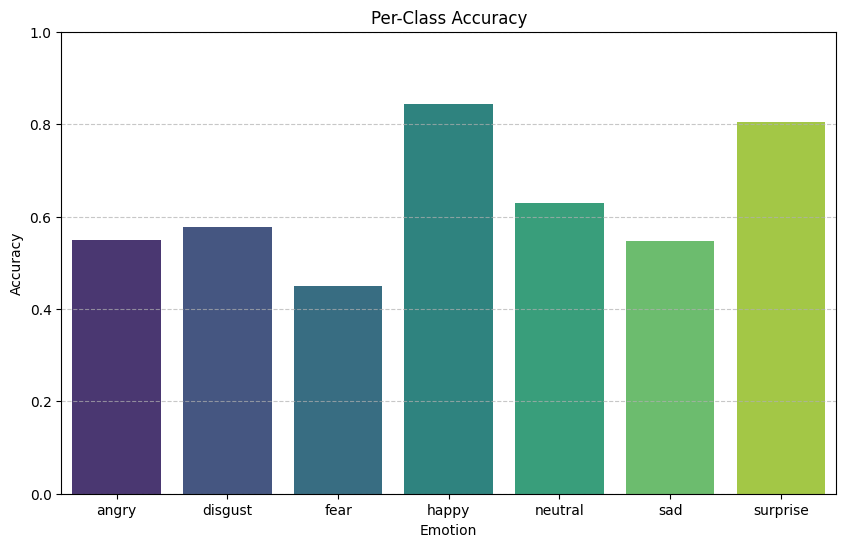

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting per-class accuracy
plt.figure(figsize=(10, 6))
sns.barplot(x='Emotion', y='Accuracy', data=per_class_accuracy_df, palette='viridis')
plt.xlabel('Emotion')
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 10.5. Overall Metrics Table

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Calculate overall accuracy from test-set predictions
overall_accuracy = accuracy_score(
    y_true,
    y_pred_classes
) * 100

# Calculate macro precision, recall, f1 from the classification report
# y_true and y_pred_classes should be available from the Confusion Matrix/Classification Report steps
macro_precision = precision_score(y_true, y_pred_classes, average='macro')
macro_recall = recall_score(y_true, y_pred_classes, average='macro')
macro_f1 = f1_score(y_true, y_pred_classes, average='macro')

# Model Size (from TFLite conversion, if already done)
# Need to run TFLite conversion cell CgHX9urQe4tR first to get this
tflite_model_path = '/content/drive/MyDrive/RSX_V4_mobile_safe.tflite'
tflite_size_mb = os.path.getsize(tflite_model_path) / (1024 * 1024) if os.path.exists(tflite_model_path) else None

# Parameters Count
total_params = model.count_params()

# Create a dictionary for the table
metrics_data = {
    'Metric': [],
    'Value': []
}

if overall_accuracy is not None:
    metrics_data['Metric'].append('Accuracy')
    metrics_data['Value'].append(f"{overall_accuracy:.2f}%")

metrics_data['Metric'].append('Precision Macro')
metrics_data['Value'].append(f"{macro_precision:.3f}")
metrics_data['Metric'].append('Recall Macro')
metrics_data['Value'].append(f"{macro_recall:.3f}")
metrics_data['Metric'].append('F1 Macro')
metrics_data['Value'].append(f"{macro_f1:.3f}")

metrics_data['Metric'].append('Model Parameters')
metrics_data['Value'].append(f"{total_params:,}")

if tflite_size_mb is not None:
    metrics_data['Metric'].append('Model Size (TFLite)')
    metrics_data['Value'].append(f"{tflite_size_mb:.2f} MB")

metrics_df = pd.DataFrame(metrics_data)
print("Overall Metrics:")
print(metrics_df.to_markdown(index=False))

Overall Metrics:
| Metric              | Value   |
|:--------------------|:--------|
| Accuracy            | 65.14%  |
| Precision Macro     | 0.636   |
| Recall Macro        | 0.629   |
| F1 Macro            | 0.631   |
| Model Parameters    | 847,747 |
| Model Size (TFLite) | 0.91 MB |


### 10.6. Mobile Deployment Metrics

In [ ]:
import pandas as pd
import os
import numpy as np
import time

# Re-calculate inference time if not already in scope or if new run
# Using existing val_gen and model from previous cells
if 'val_gen' in locals() and 'model' in locals():
    val_gen.reset()
    val_images, _ = next(val_gen)

    num_predictions = 100
    inference_times = []

    # Warm-up run
    model.predict(val_images[:1], verbose=0)

    for _ in range(num_predictions):
        start_time = time.time()
        model.predict(val_images[:1], verbose=0)
        end_time = time.time()
        inference_times.append(end_time - start_time)

    mean_inference_time_ms = np.mean(inference_times) * 1000
else:
    mean_inference_time_ms = float('nan') # Indicate not available

# Model Size (from TFLite conversion, if already done)
tflite_model_path = '/content/drive/MyDrive/RSX_V4_mobile_safe.tflite'

# Check if the TFLite model file exists
if os.path.exists(tflite_model_path):
    tflite_size_mb = os.path.getsize(tflite_model_path) / (1024 * 1024)
    print(f"TFLite model file found at: {tflite_model_path}")
else:
    tflite_size_mb = None
    print(f"Warning: TFLite model file not found at: {tflite_model_path}. Please ensure the previous cell for TFLite conversion was executed successfully and Google Drive is mounted properly.")

# Parameters Count
total_params = model.count_params()

# Create a dictionary for the table
metrics_data = {
    'Metric': [],
    'Value': []
}

metrics_data['Metric'].append('Model Size (TFLite)')
metrics_data['Value'].append(f"{tflite_size_mb:.2f} MB") if tflite_size_mb is not None else metrics_data['Value'].append('N/A')

metrics_data['Metric'].append('Parameters')
metrics_data['Value'].append(f"{total_params:,}")

metrics_data['Metric'].append('Average Keras Inference Time (Colab)')
metrics_data['Value'].append(f"{mean_inference_time_ms:.2f} ms") if not np.isnan(mean_inference_time_ms) else metrics_data['Value'].append('N/A')

metrics_df = pd.DataFrame(metrics_data)
print("Mobile Deployment Metrics:")
print(metrics_df.to_markdown(index=False))

TFLite model file found at: /content/drive/MyDrive/RSX_V4_mobile_safe.tflite
Mobile Deployment Metrics:
| Metric                               | Value    |
|:-------------------------------------|:---------|
| Model Size (TFLite)                  | 0.91 MB  |
| Parameters                           | 847,747  |
| Average Keras Inference Time (Colab) | 75.88 ms |


### 10.7. Precision, Recall, F1-Score

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(val_gen)
y_classes = np.argmax(y_pred, axis=1)
print(classification_report(val_gen.classes, y_classes, target_names=val_gen.class_indices.keys()))


449/449 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
              precision    recall  f1-score   support

       angry       0.57      0.55      0.56       958
     disgust       0.65      0.58      0.61       111
        fear       0.51      0.45      0.48      1024
       happy       0.87      0.84      0.86      1774
     neutral       0.59      0.63      0.61      1233
         sad       0.52      0.55      0.53      1247
    surprise       0.73      0.80      0.77       831

    accuracy                           0.65      7178
   macro avg       0.64      0.63      0.63      7178
weighted avg       0.65      0.65      0.65      7178



## 11. Experimental Conclusions

- The `RSX_v3` model achieved the highest overall performance among all evaluated RS-Xception variants, obtaining an accuracy of **65.16%** on the FER2013 test set while preserving the same lightweight architecture and deployment characteristics as `RSX_v2`.

- Compared to `RSX_v2`, the use of **Focal Loss** instead of the standard categorical cross-entropy loss improved the model's ability to learn difficult and underrepresented emotion classes. This resulted in higher overall accuracy, precision, recall, and F1-score without increasing the number of trainable parameters or the model size.

- The obtained results demonstrate that combining depthwise separable convolutions, residual connections, squeeze-and-excitation attention mechanisms, and Focal Loss provides an effective balance between recognition performance and computational efficiency for facial emotion recognition.

- The classification report and confusion matrix indicate strong performance on the *Happy* and *Surprise* classes, while *Fear* and *Sad* remain the most challenging emotions to classify correctly. This behavior is consistent with the characteristics of the FER2013 dataset and findings reported in the literature.

- Despite achieving higher training accuracy than validation accuracy, the model maintained stable generalization performance and achieved the best overall test-set results among the evaluated configurations.

- Furthermore, the successful conversion to *TensorFlow Lite*, together with a model size of only **0.91 MB** and fewer than **850,000 trainable parameters**, confirms the suitability of the proposed model for real-time mobile deployment within the Face2Mood application.
